### 로지스틱 회귀
- 데이터가 어떤 범주에 속할 확률을 0과 1사이의 값으로 정의
- 확률에 따라 가능성이 더 큰 범주에 속하도록 분류하는 알고리즘

### 활성 함수
- 신경망 뉴런의 출력을 결정하는 함수
- 대표적인 할성 함수
  - 시그모이드 함수: [0,1]
  - 하이퍼볼릭 탄젠트(tanH): [-1, 1]

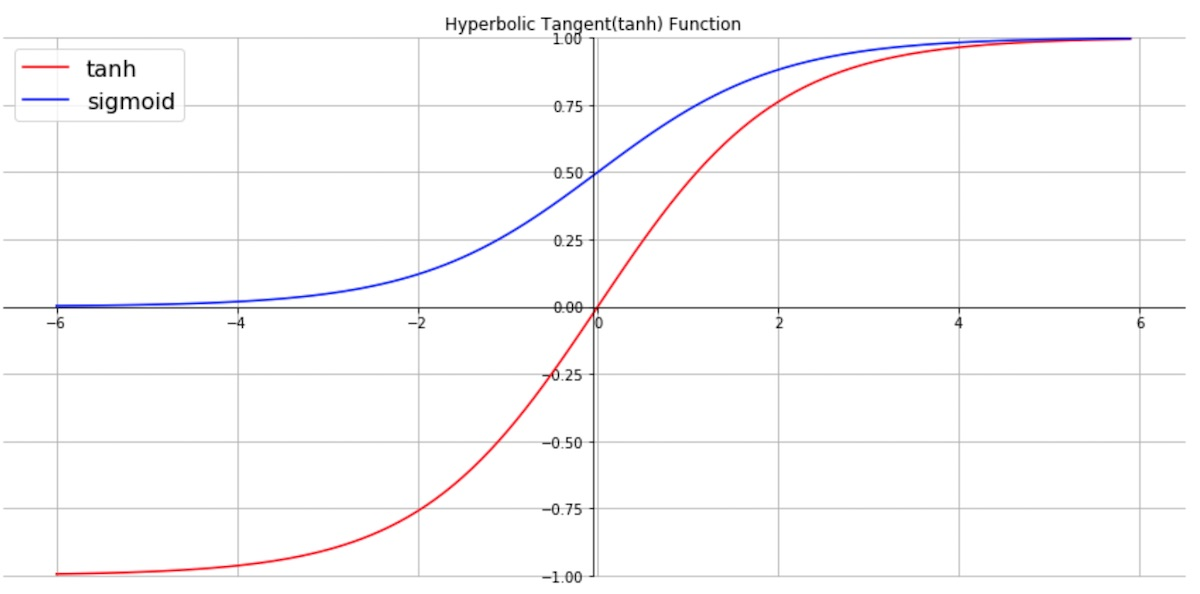

### 회귀와 분류 비교
- 분류: 주사위를 던진 값 예측의 경우
  - 실제값이 5일 때, 예측값이 1이나 6은 모두 틀린 것
- 회귀: 연봉 예측의 경우
  - 실제 연봉이 5,000만원일 때, 예측값 4,500만원은 예측값 2,000만원보다 훨씬 잘 예측한 것

### 로지스틱 회귀
- 회귀이므로 실수값을 출력하지만, 회귀보다는 분류문제에 가까움
  - 따라서, 로지스틱 회귀 문제의 목표값은 0 또는 1의 값을 가짐
- 모델의 출력값은 선형 계층과 시그모이드 함수를 거쳐서 나와 0에서 1사이의 실수값을 가짐
  - ex) 1이 목표값일 때, 0.9는 정답? 오답?, 0.1은 정답? 오답? => 절반값인 0.5보다 크면 정답 작으면 오답으로 회귀<br>따라서 0.9는 정답, 0.1은 오답이 됨

### 로지스틱 회귀의 손실함수
- 로지스틱 회귀는 0과 1의 양 극단의 확률값을 갖기 때문에 오차의 평균값을 사횽하는 선형 회귀의 손실함수인 MSE는 로지스틱 회귀이다.
  - 양 극단값의 평균은 0이 되므로 손실함수가 적절한 오차값을 제시하지 못함
- 이진 크로스엔트로피(BCE) 손실함수를 사용
  - 참인 경우와 거짓인 경우의 벡터값이 반영<br>
    $\displaystyle BCE = -\frac{1}{n} \sum_{i=1}^{n} \left( y_i^T \cdot \log \hat{y_i} + (1 - y_i)^T \cdot \log(1 - \hat{y_i}) \right)$
  - 위 식에서 왼쪽은 정답이 참 ($y_i,_j=1$)일 경우, 오른쪽은 거짓 ($1-y_i,_j = 1$)일 경우를 나타냄
  - 양쪽 중 한 쪽은 항상 0이 됨

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [3]:
df=pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['class']=cancer.target

In [4]:
df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


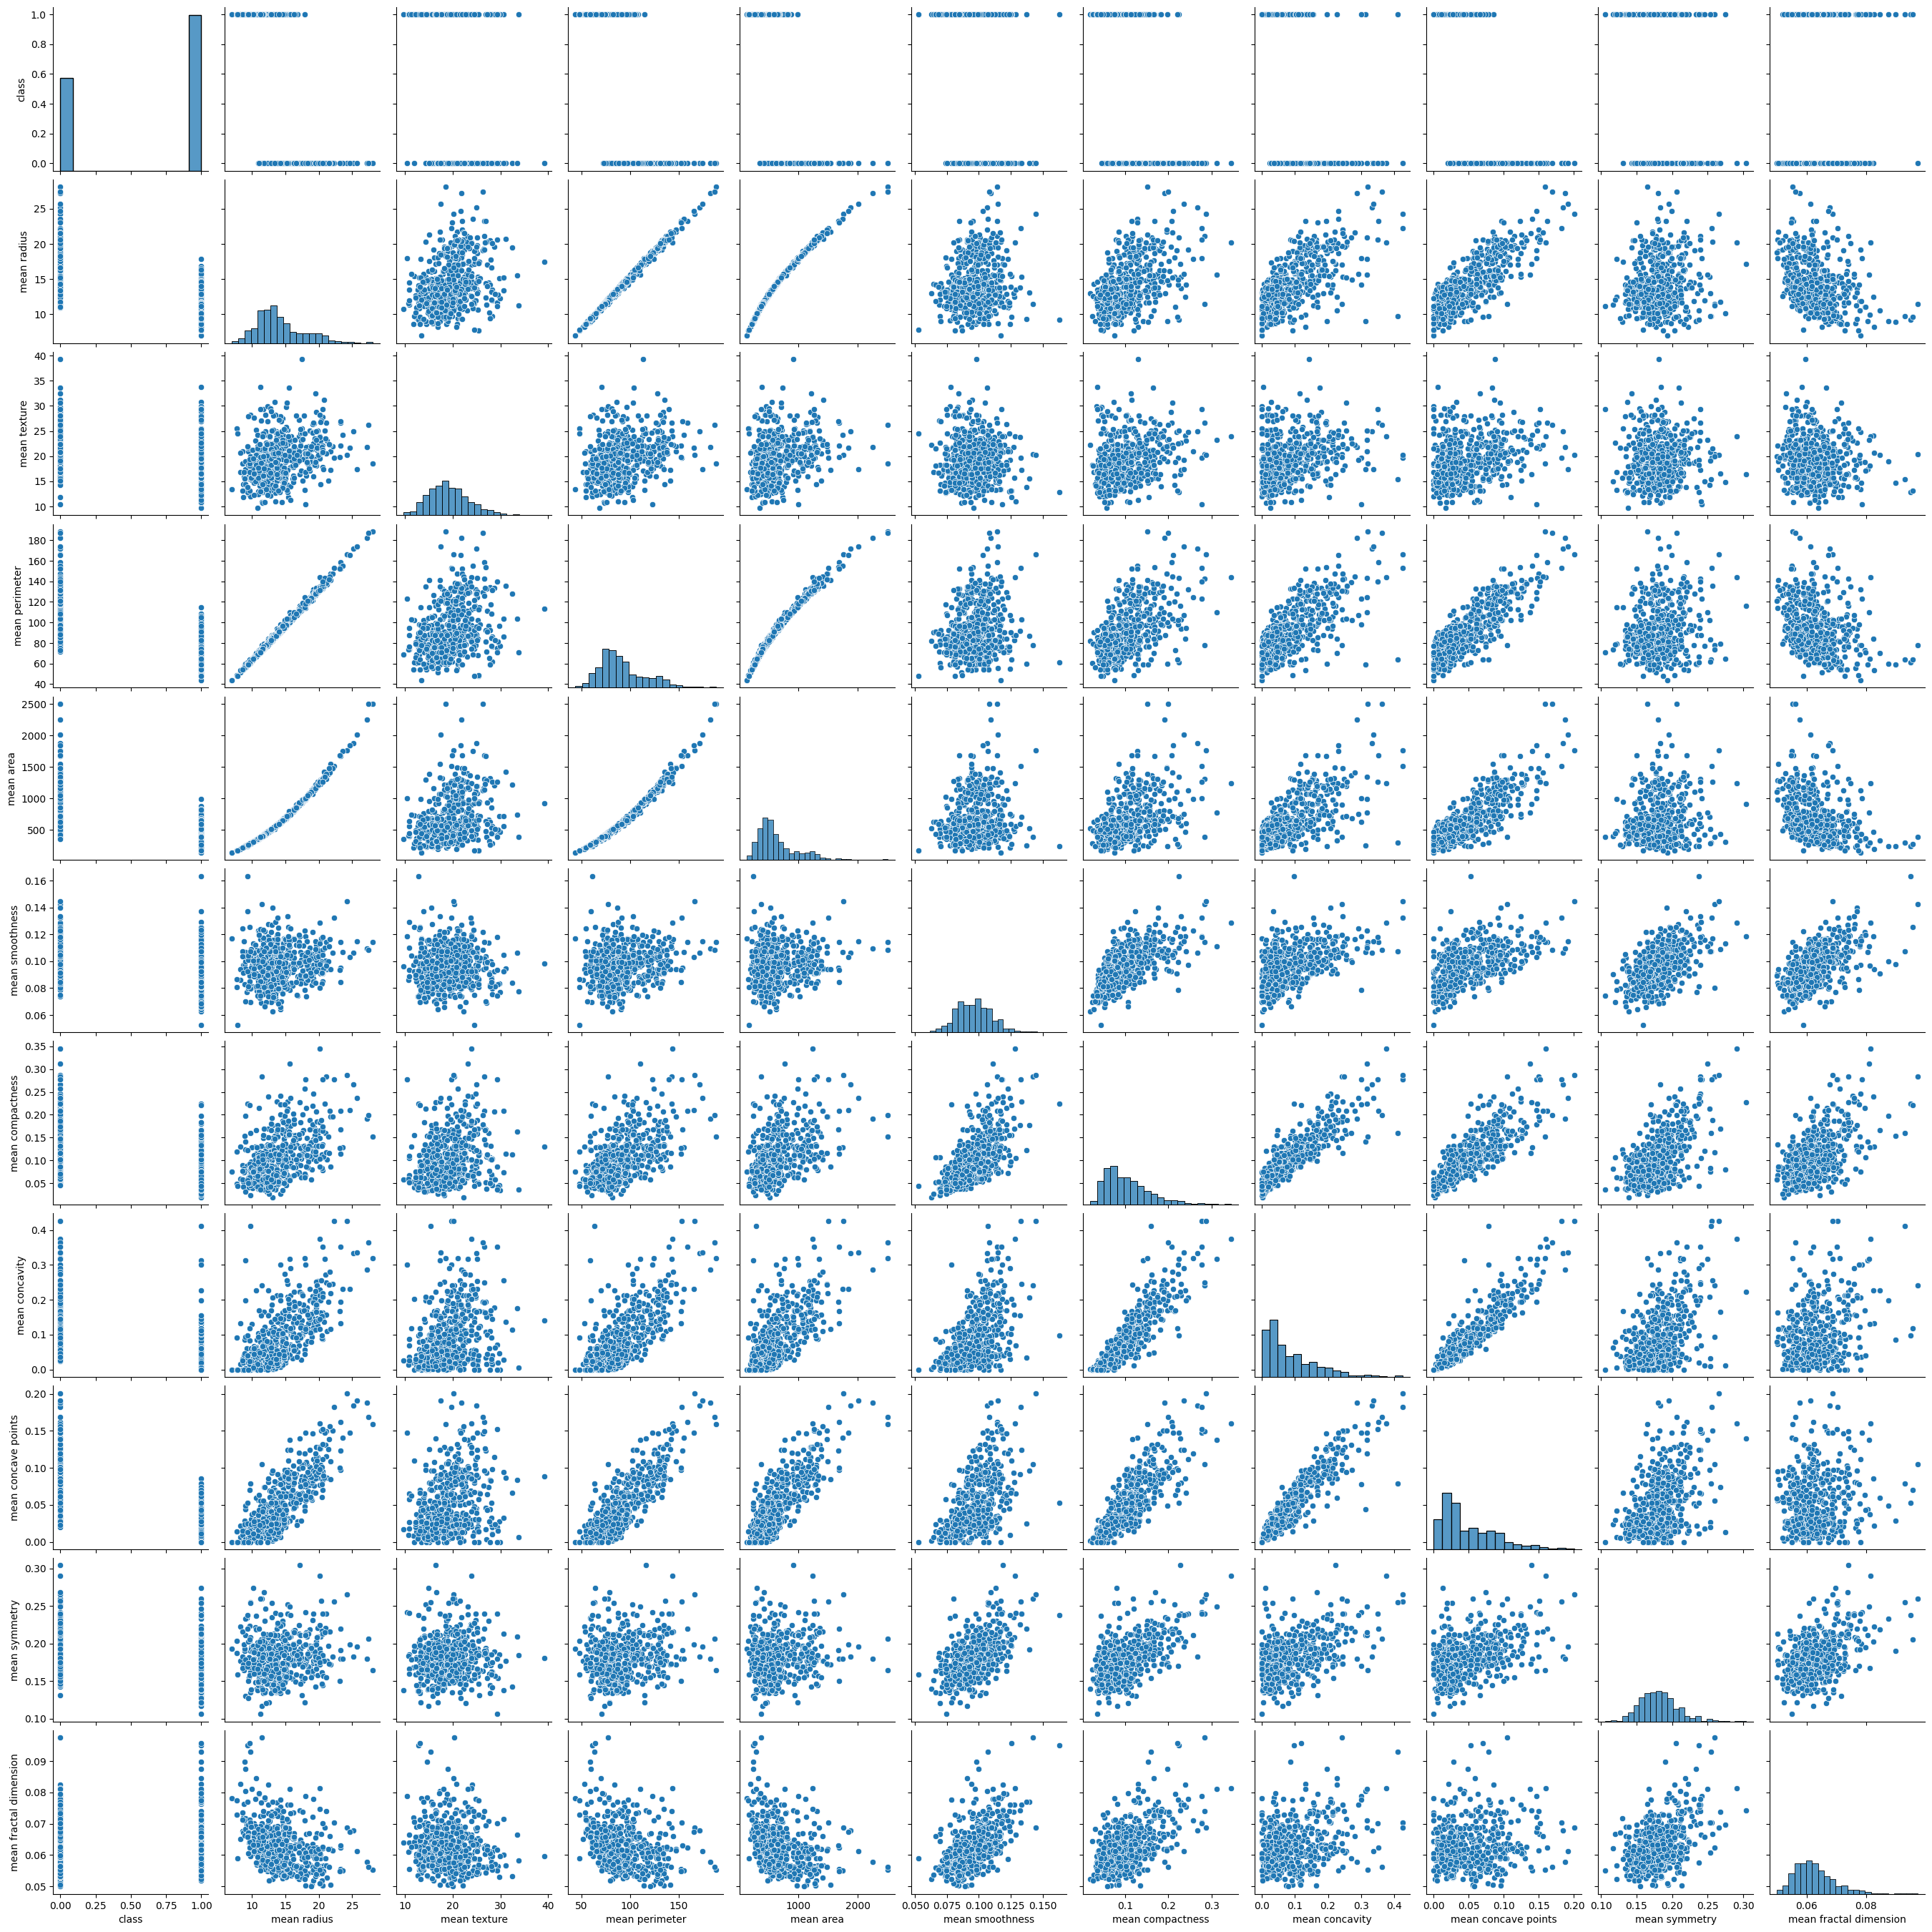

In [5]:
sns.pairplot(df[['class']+list(df.columns[:10])]) # 평균
plt.show()

- feature 간에 교집합이 없는 것이 좋음

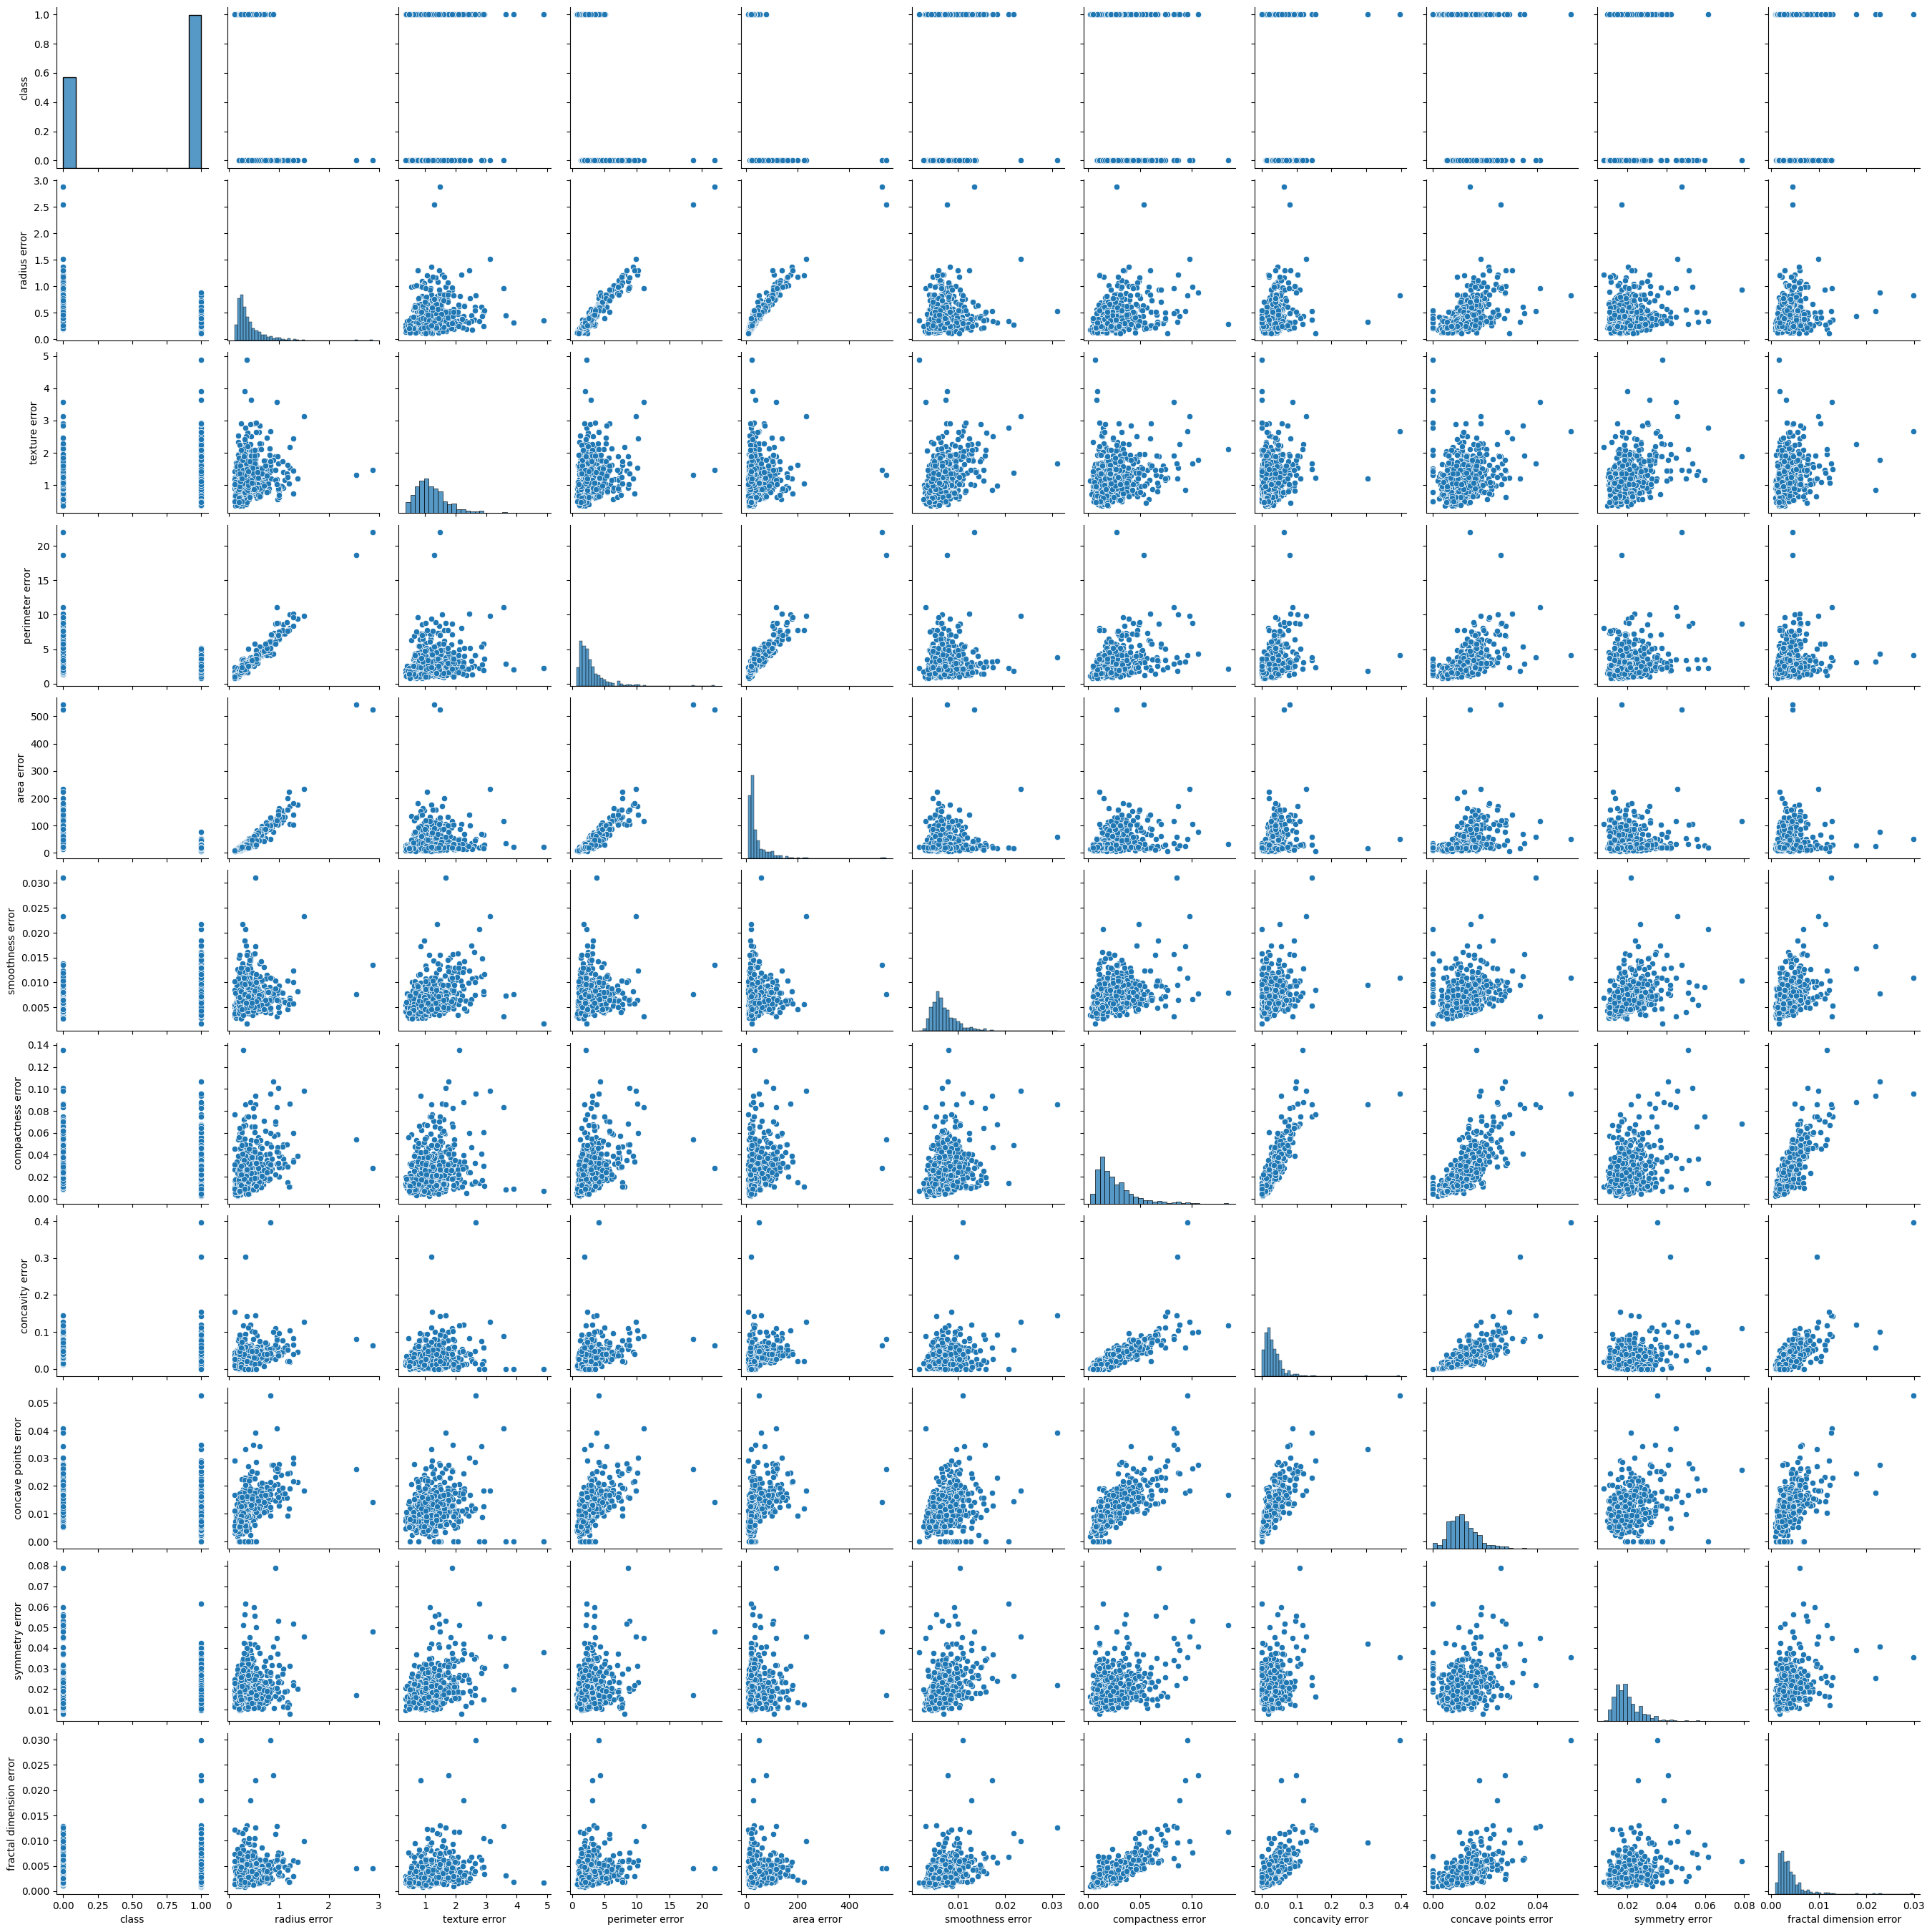

In [6]:
sns.pairplot(df[['class']+list(df.columns[10:20])]) # 표준편차
plt.show()

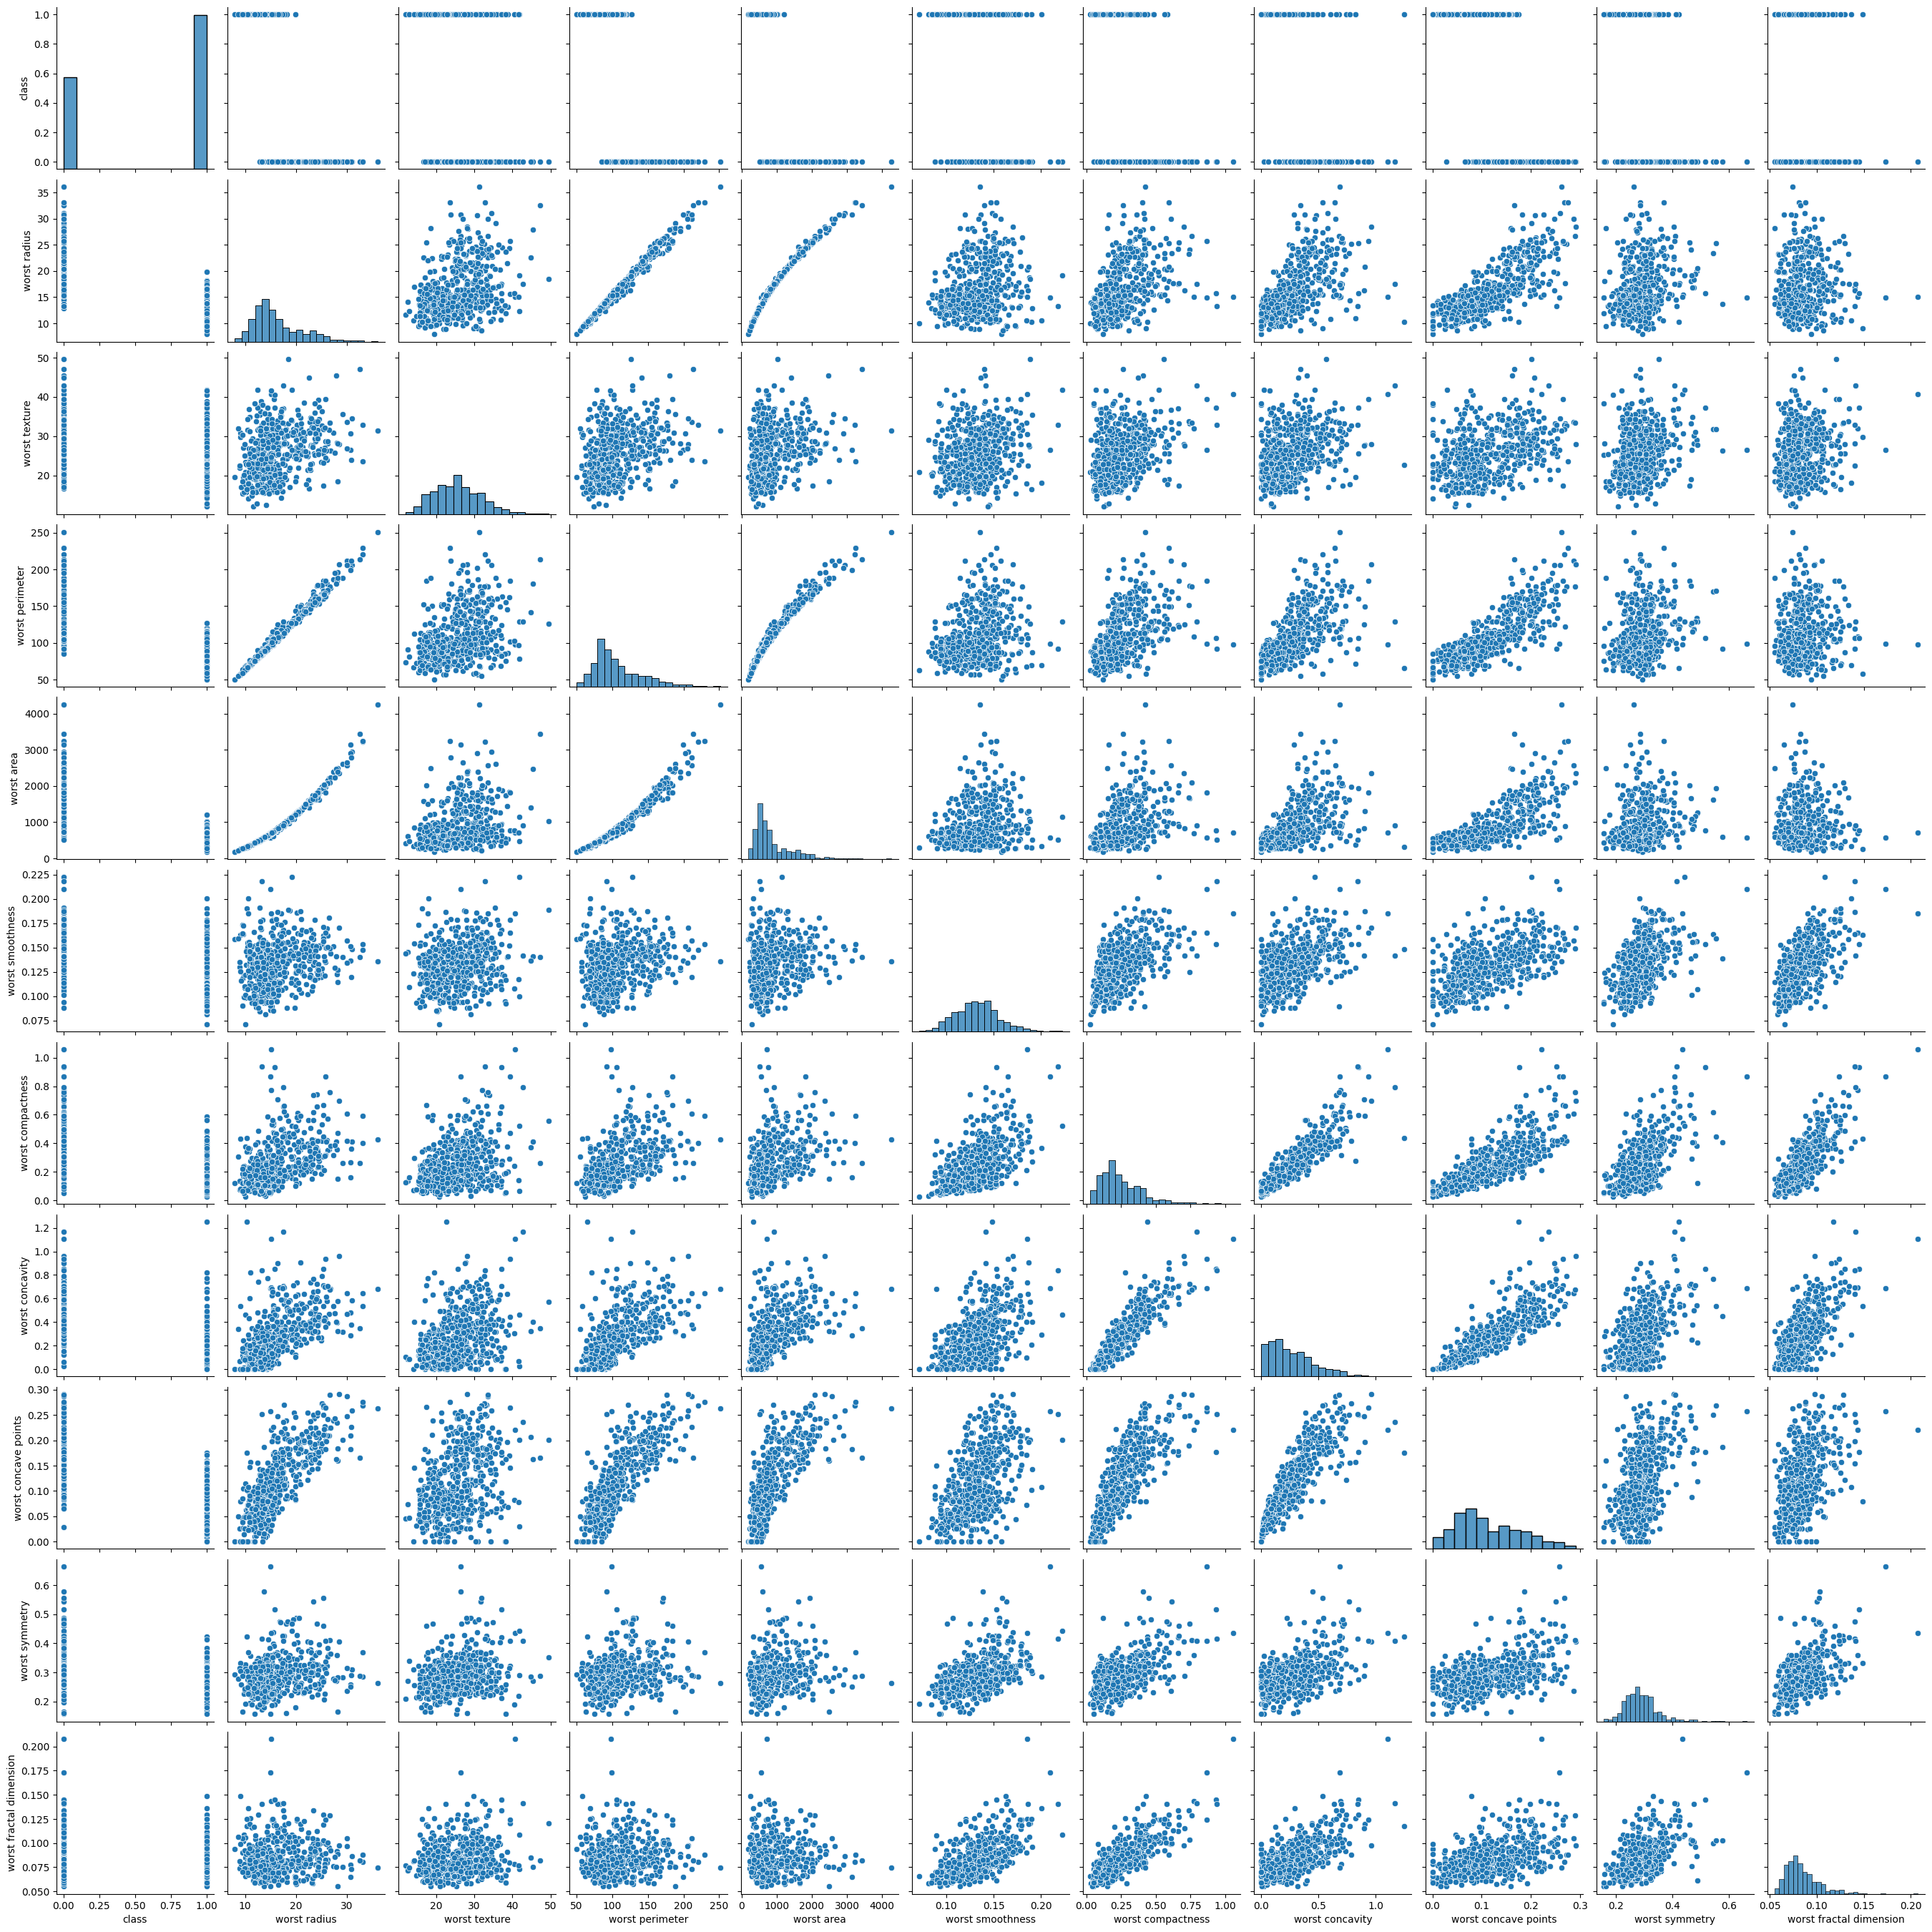

In [7]:
sns.pairplot(df[['class']+list(df.columns[20:30])]) # 최악
plt.show()

- 모양이 비슷함
- 3번의 경향이 가장 선명함

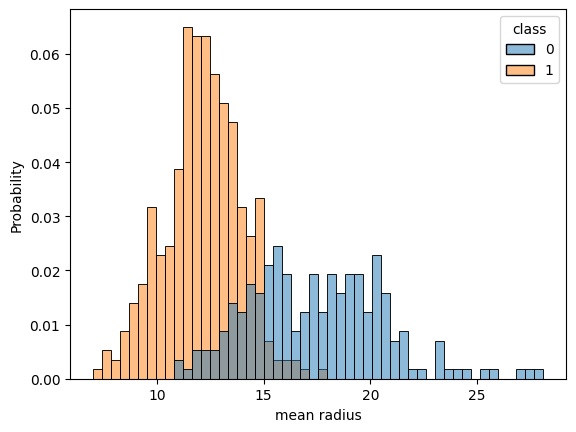

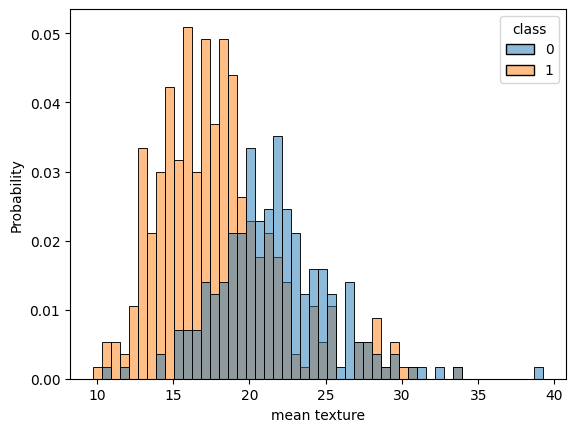

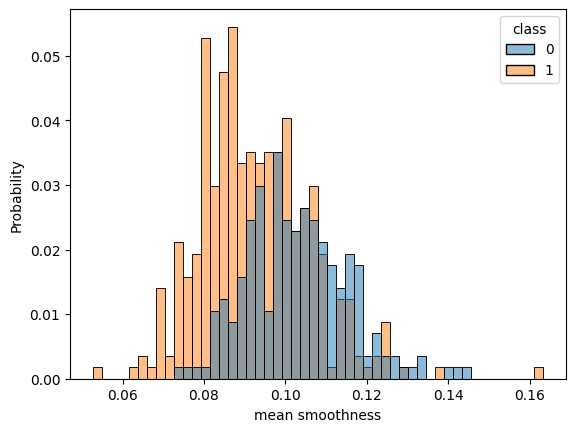

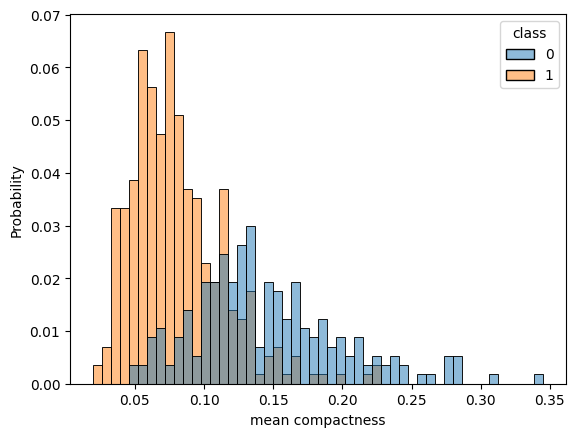

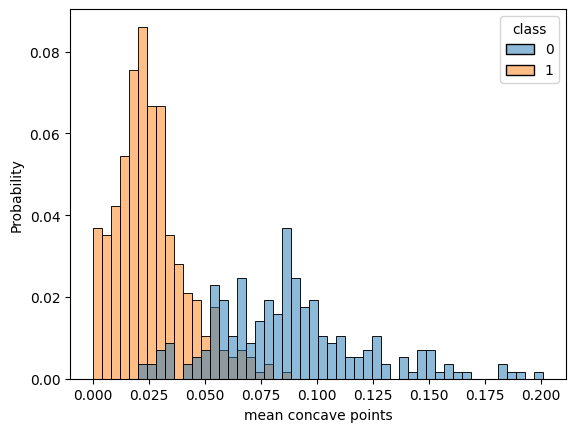

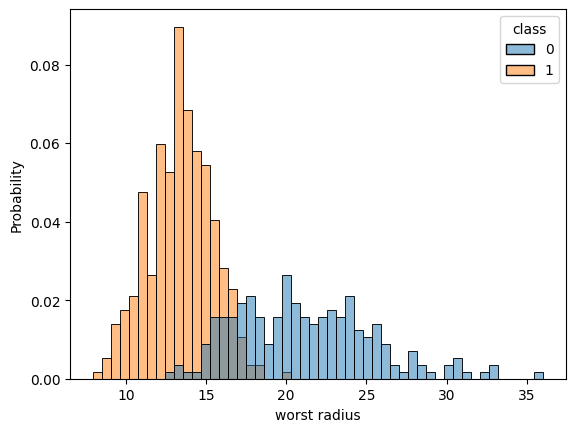

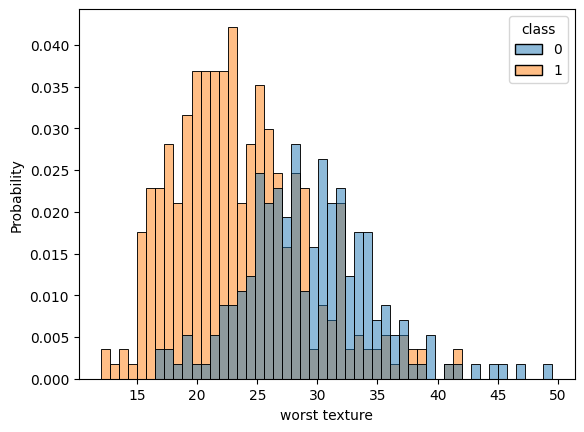

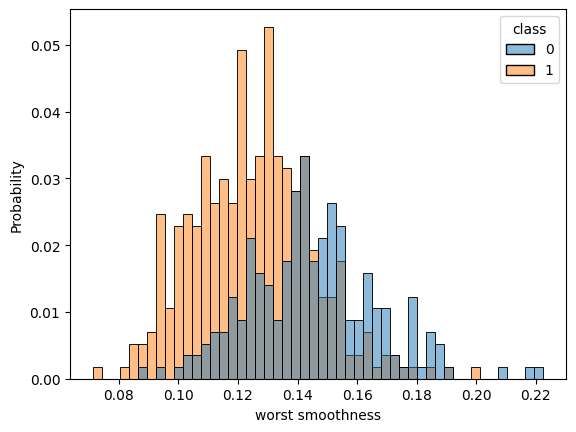

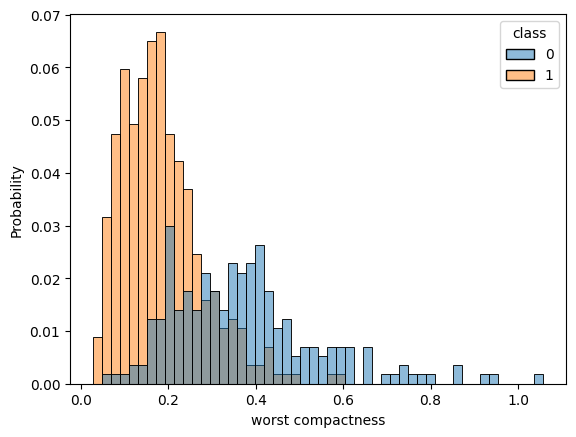

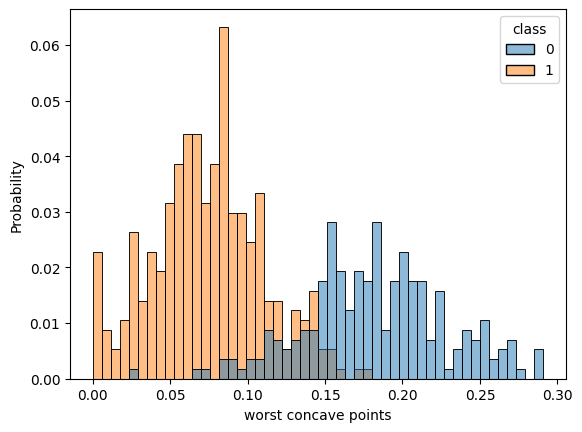

In [8]:
cols=["mean radius","mean texture","mean smoothness","mean compactness","mean concave points",
      "worst radius","worst texture","worst smoothness","worst compactness","worst concave points","class"]
for c in cols[:-1]:
    sns.histplot(df, x=c, hue=cols[-1], bins=50, stat='probability')
    plt.show()

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [10]:
# 데이터 준비
data=torch.from_numpy(df[cols].values).float()
data.shape

torch.Size([569, 11])

In [11]:
# 입력 데이터, 목표값
x=data[:, :-1]
y=data[:, -1:]
print(x.shape, y.shape)

torch.Size([569, 10]) torch.Size([569, 1])


In [12]:
# 하이퍼 파라미터
n_epochs=200000
learning_rate=1e-2
print_interval=10000

In [13]:
class MyModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        self.input_dim=input_dim
        self.output_dim=output_dim

        super().__init__()

        self.linear=nn.Linear(input_dim, output_dim)
        self.act=nn.Sigmoid()

    def forward(self, x):
        # |x|=(batch_size,input_dim)
        y=self.act(self.linear(x))
        return y

### 모델 생성, 손실함수(BCE) 적용, 최적화(SGD, 확률적 경사하강법) 적용

In [14]:
model=MyModel(input_dim=x.size(-1), output_dim=y.size(-1))
crit=nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

### 학습 진행
- 선형 회귀와 같은 코드로 학습
- 순전파(forward) &rarr; 손실계산 &rarr; 경사값 초기화 &rarr; 역전파(backward) &rarr; 최적화

In [15]:
for i in range(n_epochs):
    y_hat=model(x)
    loss=crit(y_hat, y)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    if (i+1)%print_interval==0:
        print('Epoch %d: loss=%.4e' % (i+1, loss))

C:\Users\legna\AppData\Local\Temp\ipykernel_11724\2858057396.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  print('Epoch %d: loss=%.4e' % (i+1, loss))


Epoch 10000: loss=2.7247e-01
Epoch 20000: loss=2.2585e-01
Epoch 30000: loss=1.9786e-01
Epoch 40000: loss=1.7949e-01
Epoch 50000: loss=1.6660e-01
Epoch 60000: loss=1.5707e-01
Epoch 70000: loss=1.4974e-01
Epoch 80000: loss=1.4393e-01
Epoch 90000: loss=1.3920e-01
Epoch 100000: loss=1.3527e-01
Epoch 110000: loss=1.3196e-01
Epoch 120000: loss=1.2912e-01
Epoch 130000: loss=1.2666e-01
Epoch 140000: loss=1.2450e-01
Epoch 150000: loss=1.2260e-01
Epoch 160000: loss=1.2090e-01
Epoch 170000: loss=1.1938e-01
Epoch 180000: loss=1.1801e-01
Epoch 190000: loss=1.1676e-01
Epoch 200000: loss=1.1562e-01


### 정확률 계산
- 모델의 결과값(y_hat)은 시그모이드 함수의 결과값이므로 0과 1에 가까운 실수값임
- y_hat > 0.5의 결과는 참과 거짓으로 나오므로 정답값(0 or 1)과 비교가 가능함

In [16]:
correct_cnt=(y==(y_hat>.5)).sum()
total_cnt=float(y.size(0))
print('Accuracy: %.4f' % (correct_cnt / total_cnt))

Accuracy: 0.9649


### 결과 확인 -시각화

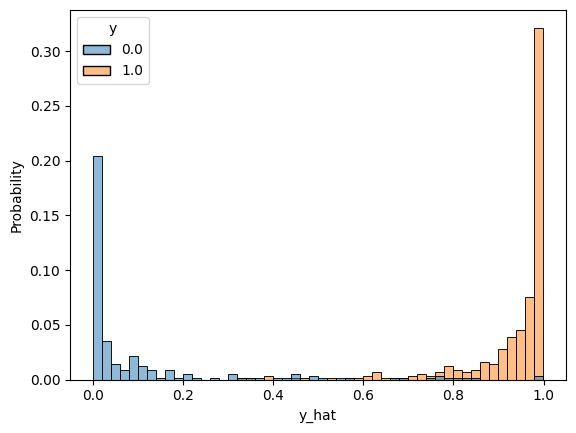

In [17]:
df=pd.DataFrame(torch.cat([y,y_hat],dim=1).detach().numpy(), columns=["y","y_hat"])
sns.histplot(df, x='y_hat', hue='y', bins=50, stat='probability')
plt.show()

- 가운데에 있는 일부 데이터를 제외하고 대부분의 샘플이 0과 1에 가깝게 나옴
- 모델이 매우 예측을 잘함(정확률: 0.9649)

## 심층 신경망
- 선형 계층 -> 선형 함수 -> 선형 데이터로 이루어진 선형 문제만 해결 가능
- 비선형 데이터
  - 감기에 걸렸을 때 날짜 경과에 따른 증상 발현의 정도 -> 가우시안 분포

### 선형 계층으로 이루어진 다층신경망
- 여전히 선형 함수이므로 비선형 문제를 해결할 수 없음
- ex) 두 층이 선형 계층으로 구성된 다층신경망의 수식

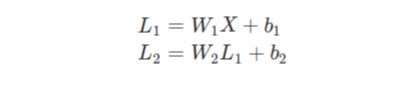<br>
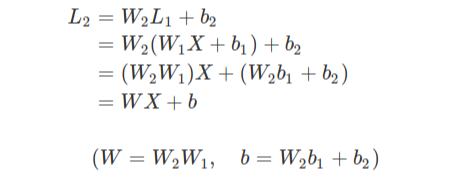

- 두 선형 계층을 통과하는 것은 또 다른 하나의 선형 계층을 통과하는 것과 같음

### 해결방법: 비선형 활성화함수 추가
- 다음 해결으로 넘어가기 전에 비선형 할성화 함수를 통과함으로써 비선형 문제 해결
- 대표적인 비선형 활성화 함수
  - 시그모이드 함수
  - 하이퍼볼릭 탄젠트(tanH) 함수

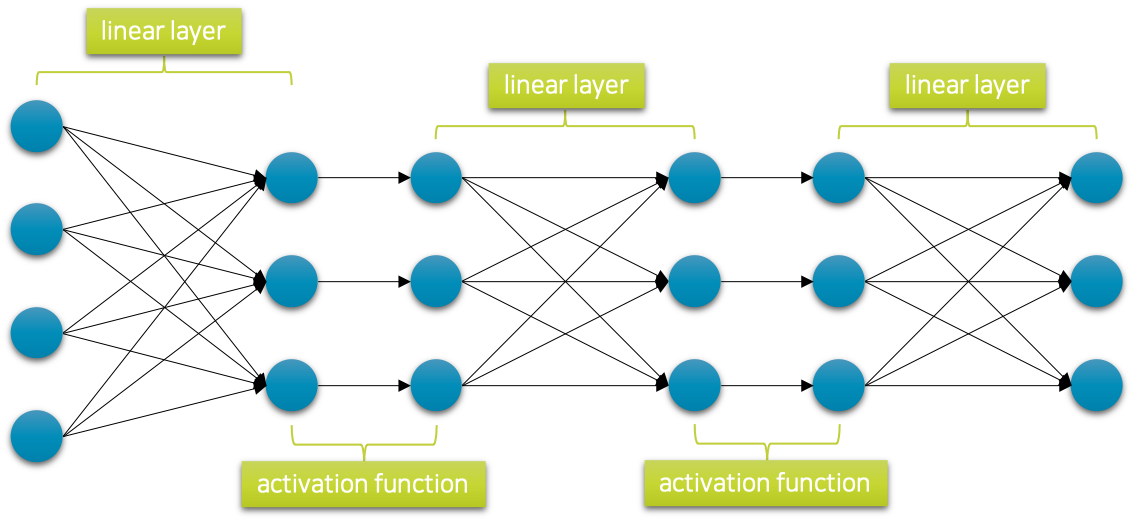

### 심층신경망의 학습
- 계층이 많아진 만큼 가중치 파라미터도 많아짐
- 학습을 위해서는 손실함수의 미분이 필요함
  - 입력단에 가까운 계층의 파라미터($W_1$)일수록 훨씬 복잡한 수식이 됨

### 역전파
- 체인 룰(chain rule)을 통해 구현<br>
  $y=g \circ f(x)$
- 위 식에서 y를 x에 대해서 미분하려면 g와 f 함수를 모두 전개하여 미분함 &rarr; 매우 복잡한 식
- 매개변수 h를 추가<br>
  $y=g(h)$<br>
  $h=f(x)$
- 체인 룰을 적용<br>
  $\displaystyle \frac{\partial y}{\partial x} = \frac{\partial y}{\partial h} \frac{\partial h}{\partial x}$
- 계산된 미분값을 전달하여 다른 계층의 미분을 구할 때 재사용
- 출력 계층 쪽의 미분이 순차적으로 입력단 쪽으로 거꾸로 전달됨 &rarr; 역전파
- 심층신경망도 같은 방식으로 적용할 수 있음

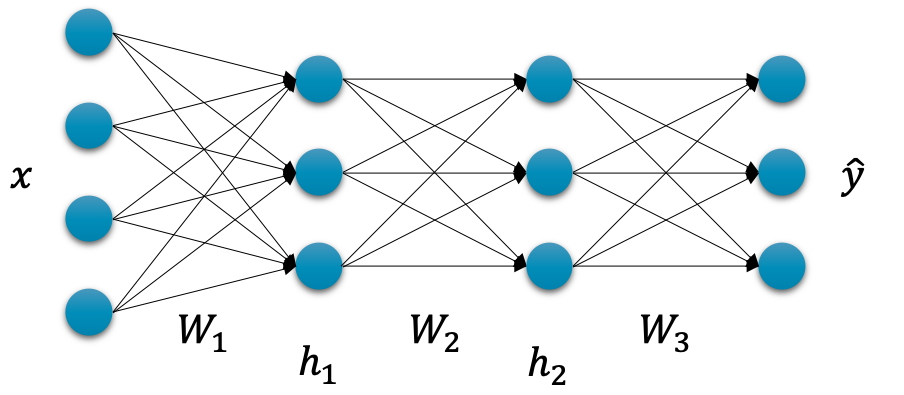

- 위 그림의 신경망에서 $\hat{y}_i$를 구하려면 다음 수식의 과정을 거치게 됨<br>
  $\hat{y}_i = h_2,_i \cdot W_3 + b_3$<br>
  $h_2,_i = \sigma(h_1,_i \cdot W_2 + b_2)$<br>
  $h_1,_i = \sigma(x_i \cdot W_1 + b_i)$
- 위 과정에 대해서 각 파라미터를 업데이트하기 위해 그래디언트 즉, 손실함수($L(\theta)$)를 가중치(W)로 미분한 값을 구하는 과정은 아래와 같이 체인 룰을 통해 간단한 수식들의 미분 곱으로 표현할 수 있음<br>
  $\displaystyle \frac{\partial L}{\partial W_3} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial W_3}$<br>
  $\displaystyle \frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial h_2} \cdot \frac{\partial h_2}{\partial W_2}$<br>
  $\displaystyle \frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial h_2} \cdot \frac{\partial h_2}{\partial h_1} \cdot \frac{\partial h_1}{\partial W_1}$
- 위의 마지막 식을 $W_1$에 대해서 전개한 후에 미분하는 것보다 위처럼 4단계의 미분을 계산하는 것이 간단함
- 예를 들어, $h_2$를 $W_2$로 미분하는 것은 아래처럼 간단히 계산할 수 있음<br>
   $\displaystyle \frac{\partial h_2}{\partial W_2} = \nabla w_2 h_2 = \nabla w_2\sigma(h_1\cdot+b_2)$
- 그리고 반복적으로 나타나는 $\displaystyle\frac{\partial L}{\partial \hat{y}}$나 $\displaystyle\frac{\partial \hat{y}}{\partial h_2}$는 한 번 계산해 두면 계속 사용할 수 있음

- 할 때마다 계산할 필요없이 한 번만 계산해두면 미분한 값을 계속 사용할 수 있음
- 단점: 우리의 신경세포를 모방 -> 신경세포에는 역전파가 없음

### 그래디언트 소실(역전파의 문제점)
- 시그모이드 함수나 하이퍼볼릭 탄젠트 함수의 미분은 0에서 최대 1(시그모이드는 1보다 훨씬 작은 값)을 가지고, 양 끝단으로 가면 0에 수렴함

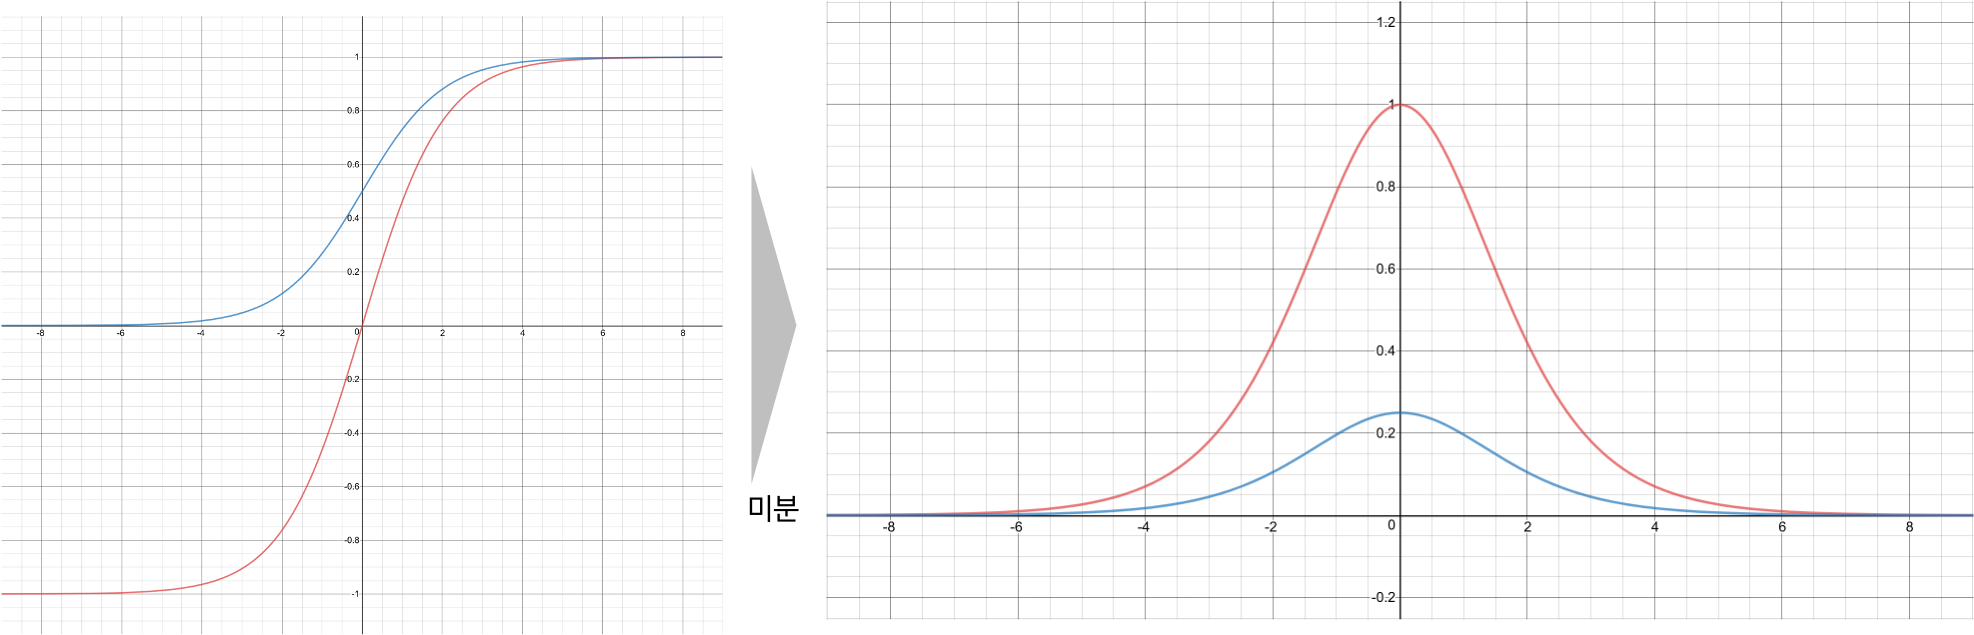

- 체인 룰에 의해 그래디언트는 편미분값들의 곱으로 이루어지는데 그 중에 1보다 작은 값이 들어가므로 입력단 쪽으로 갈수록 그래디언트는 점점 작아짐
  - 학습이 진행되어 오차값이 작아지면 그 값이 더욱 작아져서 결국 0으로 소실됨
    - 그래디언트 값이 0에 근접할수록 학습의 진행도가 떨어짐(학습이 되지 않음)

### 렐루(ReLU)
- 기존 활성 함수의 단점을 보완<br>$y=ReLU(x)=max(0,x)$
- 음수 구간은 모두 0, 양수 구간은 기울기가 전부 1인 함수
- 장점: 양수 구간에 있으면 그래디언트 소실이 발생하지 않음
- 단점: 음수 구간은 기울기도 0이 되므로 학습이 전혀 되지 않음
- 미분의 최댓값 1 => 1은 무시해도 되는 값<br>(학습 시 그 값 때문에 손실이 왜곡되거나 스케일링 문제가 생기지 않음,기울기에 영향이 없기 때문)

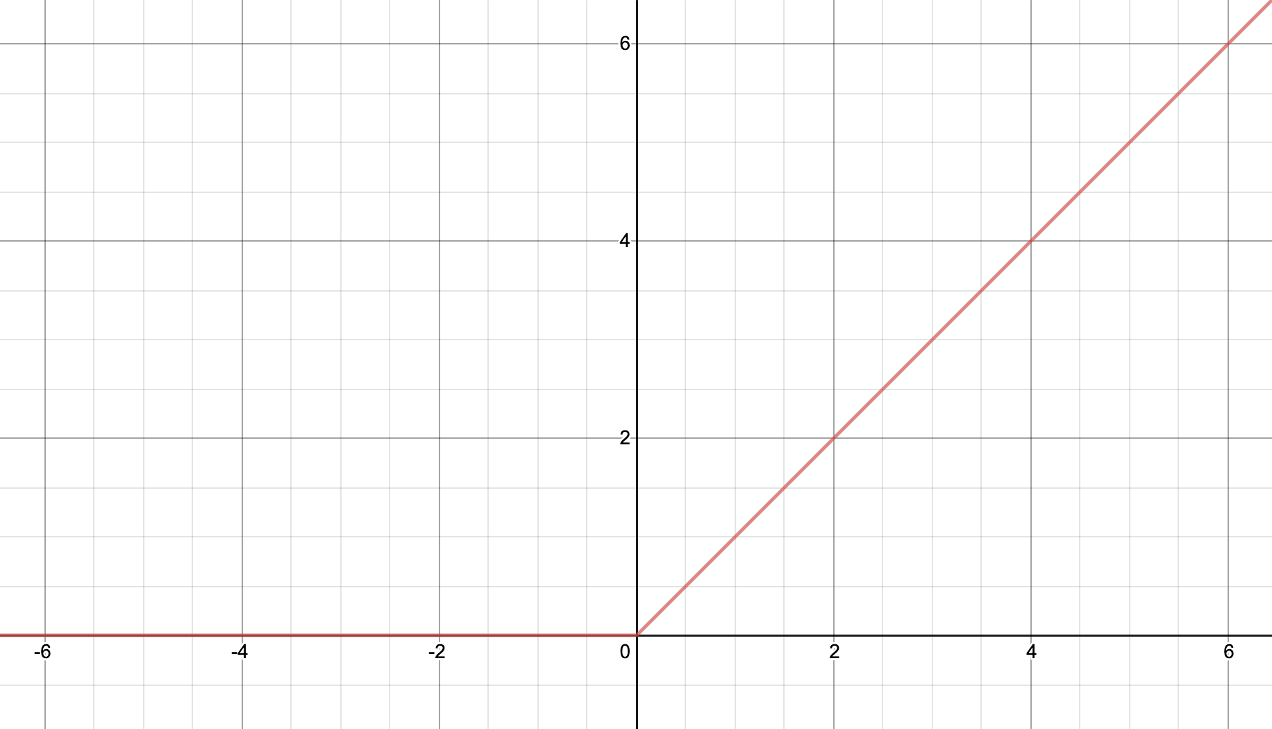

### 리키렐루(leaky ReLU)
- ReLU의 단점을 보완<br>
  $y=ReLU(x)=max(0,x), \quad where \;0 \leq \alpha < 1$
- 음수 구간에 0보다 조금 큰 기울기를 가진 함수를 적용하여 어느정도 학습이 이루어지도록 함
- 렐루와 리키렐루의 장단점이 모두 존재하기에 두 개를 모두 사용함
  - 문제에 따라 사용됨

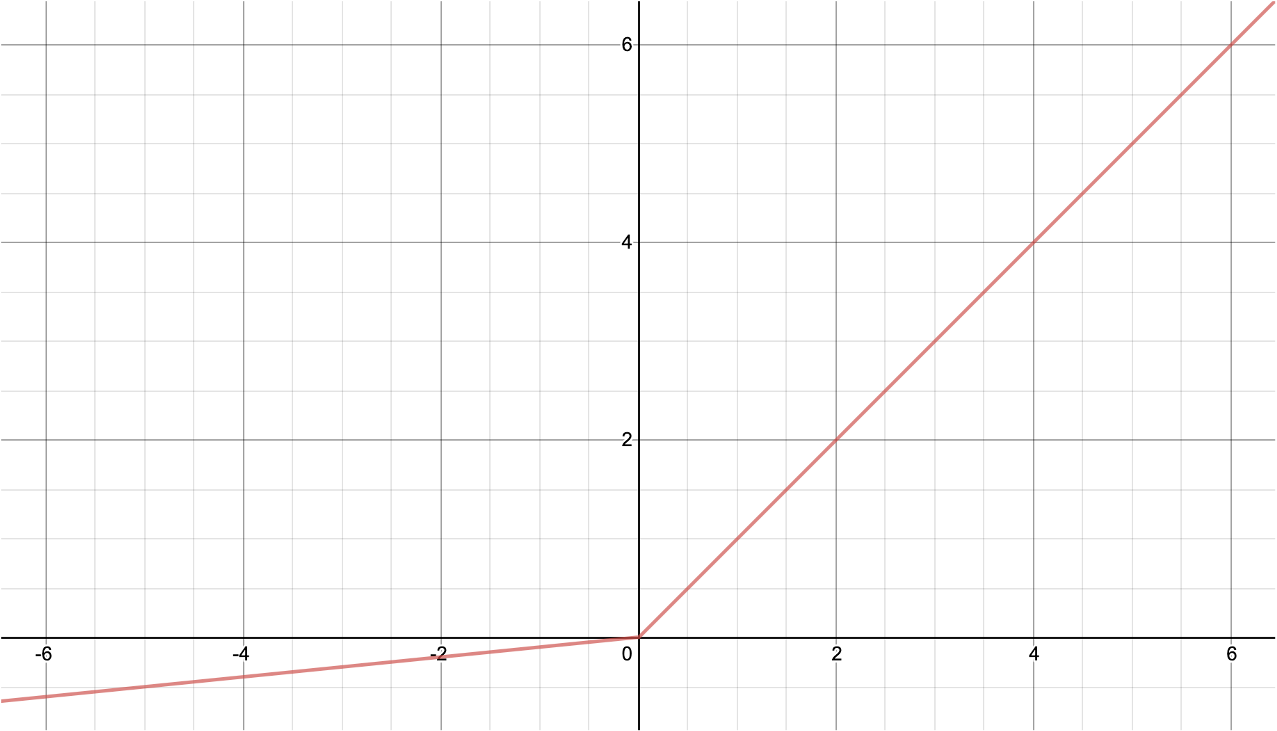

- 정규화가 필요한 이유
  - feature 열 중에서 첫 번째 열 값의 범위가 -10,000 ~ 10,000이고, 두 번째는 0 ~ 10이라면
    - 10의 크기로 변하는 것은 첫 번째 열에서는 미미한 변화이지만,
    - 두 번째 열은 양 극단을 오고 가는 변화임
  - 열의 특징에 맞춰 적절한 계수를 곱하여 변화를 상쇄할 수도 있으나.
  - 적정한 정규화를 거치면 최적화에 유리함
  - 10이든 1000이든 절댓값 자체는 중요하지 않고, 특성들끼리의 상대적인 비율을 맞춰주는 게 중요

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pltb

from sklearn.preprocessing import StandardScaler

In [19]:
import numpy as np
data_url = "https://lib.stat.cmu.edu/datasets/boston"
raw_df=pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data=np.hstack([raw_df.values[::2, :], raw_df.values[1::2,:2]])
target=raw_df.values[1::2,2]

feature_names= ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT']
df=pd.DataFrame(data, columns=feature_names)
df["TARGET"] = target
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,TARGET
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0.0,0.573,6.030,80.8,2.5050,1.0,273.0,21.0,396.90,7.88,11.9


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [15]:
scaler=StandardScaler()
scaler.fit(df.values[:,:-1])
df.iloc[:,:-1] = scaler.transform(df.values[:,:-1]).round(4)
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,TARGET
501,-0.4132,-0.4877,0.1157,-0.2726,0.1581,0.4393,0.0187,-0.6258,-0.9828,-0.8032,1.1765,0.3872,-0.4181,22.4
502,-0.4152,-0.4877,0.1157,-0.2726,0.1581,-0.2345,0.2889,-0.7166,-0.9828,-0.8032,1.1765,0.4411,-0.5008,20.6
503,-0.4134,-0.4877,0.1157,-0.2726,0.1581,0.9850,0.7974,-0.7737,-0.9828,-0.8032,1.1765,0.4411,-0.9830,23.9
504,-0.4078,-0.4877,0.1157,-0.2726,0.1581,0.7257,0.7370,-0.6684,-0.9828,-0.8032,1.1765,0.4032,-0.8653,22.0
505,-0.4150,-0.4877,0.1157,-0.2726,0.1581,-0.3628,0.4347,-0.6132,-0.9828,-0.8032,1.1765,0.4411,-0.6691,11.9


In [29]:
data=torch.from_numpy(df.values).float()

x=data[:, :-1]
y=data[:, -1:]

In [30]:
n_epochs=200000
learning_rate=1e-4
print_interval=10000

In [31]:
class MyModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        self.input_dim=input_dim
        self.output_dim=output_dim

        super().__init__()

        self.linear1=nn.Linear(input_dim, 3)
        self.linear2=nn.Linear(3, 3)
        self.linear3=nn.Linear(3, 3)
        self.linear4=nn.Linear(3, output_dim)
        self.act=nn.ReLU()

    def forward(self, x):
        # |x|=(batch_size,input_dim)
        h=self.act(self.linear1(x))
        h=self.act(self.linear2(x))
        h=self.act(self.linear3(x))
        y=self.linear4(x)
        return y

model=MyModel(x.size(-1), y.size(-1))
print(model)

MyModel(
  (linear1): Linear(in_features=13, out_features=3, bias=True)
  (linear2): Linear(in_features=3, out_features=3, bias=True)
  (linear3): Linear(in_features=3, out_features=3, bias=True)
  (linear4): Linear(in_features=3, out_features=1, bias=True)
  (act): ReLU()
)


In [32]:
model=nn.Sequential(
    nn.Linear(x.size(-1),3),
    nn.LeakyReLU(),
    nn.Linear(3,3),
    nn.LeakyReLU(),
    nn.Linear(3,3),
    nn.LeakyReLU(),
    nn.Linear(3,3),
    nn.LeakyReLU(),
    nn.Linear(3,y.size(-1)),
)
print(model)

Sequential(
  (0): Linear(in_features=13, out_features=3, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=3, out_features=3, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=3, out_features=3, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=3, out_features=3, bias=True)
  (7): LeakyReLU(negative_slope=0.01)
  (8): Linear(in_features=3, out_features=1, bias=True)
)


- 회귀문제(선형) -> 하나의 값이 나와야 함, but 마지막에 렐루를 넣으면 하나의 값이 나오지 않음
- 그래서 마지막에 nn.LeakyReLU()를 넣지 않음, y.size(-1)의 값 즉, 하나의 값이 출력되어야 함
- 만약 다른 문제라면 형태가 달라질 수 있음

In [33]:
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

for i in range(n_epochs):
    y_hat=model(x)
    loss=F.mse_loss(y_hat, y)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    if (i+1)%print_interval==0:
        print('Epoch %d: loss=%.4f' % (i+1, loss))

Epoch 10000: loss=9.7054
Epoch 20000: loss=7.5938
Epoch 30000: loss=6.6456
Epoch 40000: loss=6.4696
Epoch 50000: loss=6.3961
Epoch 60000: loss=6.3750
Epoch 70000: loss=6.3645
Epoch 80000: loss=6.3581
Epoch 90000: loss=6.3521
Epoch 100000: loss=6.3417
Epoch 110000: loss=6.3359
Epoch 120000: loss=6.3322
Epoch 130000: loss=6.3288
Epoch 140000: loss=6.3254
Epoch 150000: loss=6.3222
Epoch 160000: loss=6.3192
Epoch 170000: loss=6.3164
Epoch 180000: loss=6.3138
Epoch 190000: loss=6.3113
Epoch 200000: loss=6.3090


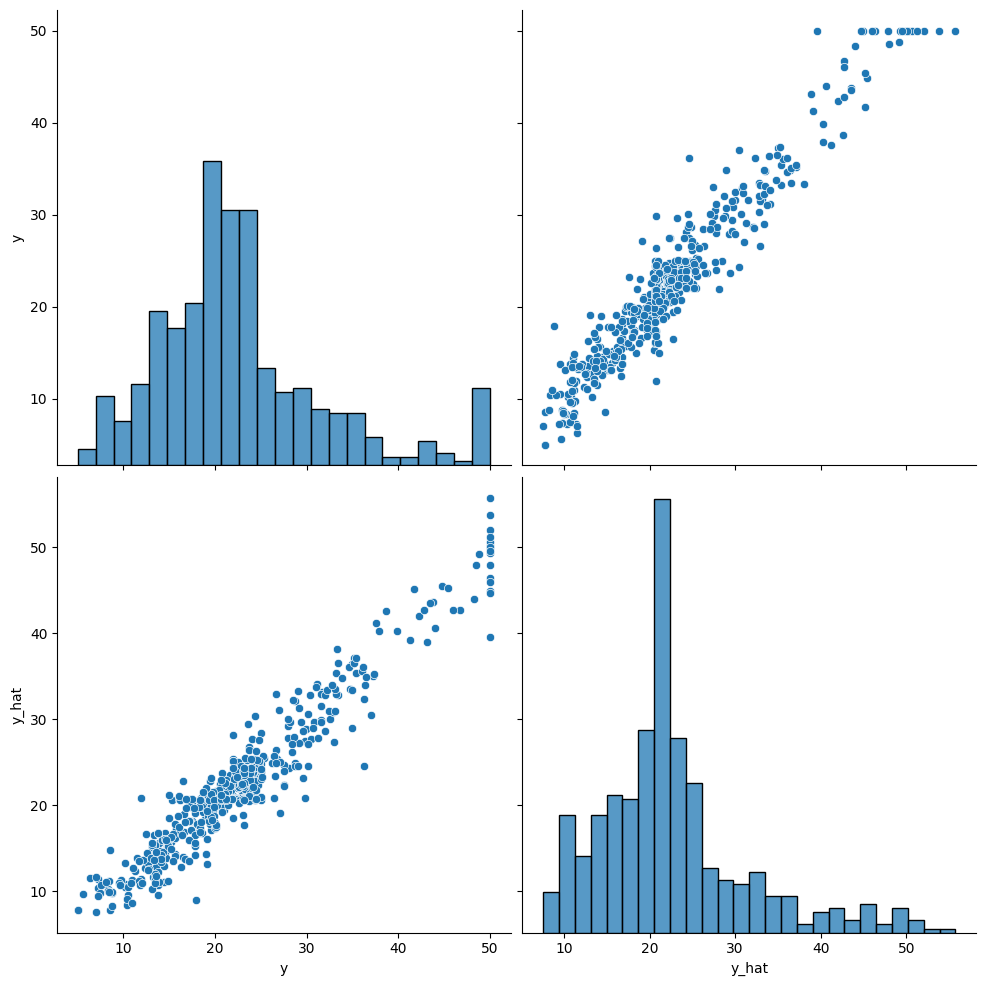

In [34]:
df=pd.DataFrame(torch.cat([y, y_hat], dim=1).detach_().numpy(),
                columns=["y","y_hat"])
sns.pairplot(df, height=5)
plt.show()